In [1]:
!pip install pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
!unzip -q student.zip

df = pd.read_csv("student-mat.csv", sep=";")

print("✅ Dataset loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded!
Shape: 395 rows × 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print("📋 Column Names:\n", df.columns.tolist())
print("\n📊 Data Types:\n", df.dtypes)
print("\n📐 Shape:", df.shape)

📋 Column Names:
 ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

📊 Data Types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1       

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
print("🔍 Missing Values:\n")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

🔍 Missing Values:

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing: 0


In [7]:
questions = [
    "1. Does study time affect final grades (G3)?",
    "2. Do students who failed before score lower now?",
    "3. Does internet access at home help performance?",
    "4. Is there a gender difference in grades?",
    "5. Does parental education level impact student grades?",
    "6. Does alcohol consumption affect grades?",
]
for q in questions:
    print(q)

1. Does study time affect final grades (G3)?
2. Do students who failed before score lower now?
3. Does internet access at home help performance?
4. Is there a gender difference in grades?
5. Does parental education level impact student grades?
6. Does alcohol consumption affect grades?


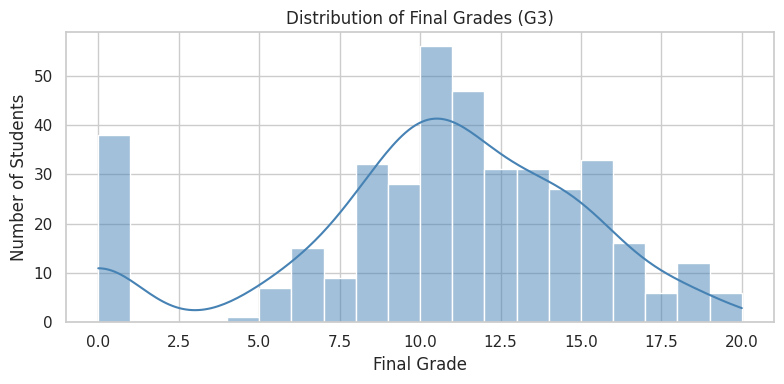

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["G3"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1511/4061167529.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="studytime", y="G3", data=df, palette="Blues")


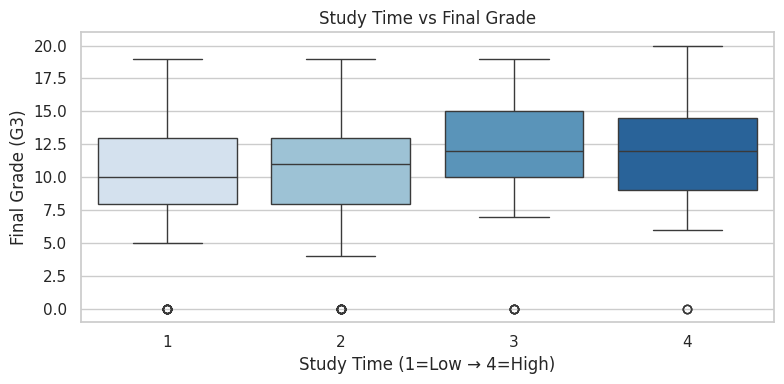

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="studytime", y="G3", data=df, palette="Blues")
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=Low → 4=High)")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1511/3320706852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sex", y="G3", data=df, palette="Set2")


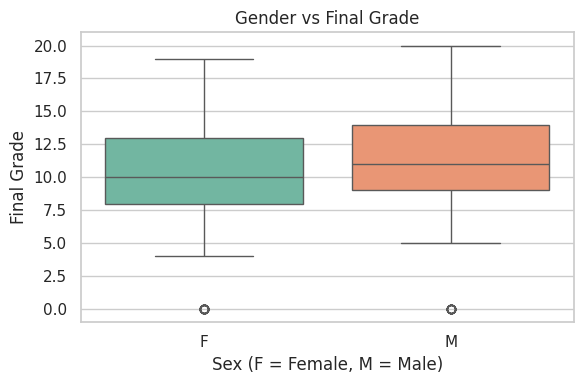

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="sex", y="G3", data=df, palette="Set2")
plt.title("Gender vs Final Grade")
plt.xlabel("Sex (F = Female, M = Male)")
plt.ylabel("Final Grade")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1511/1622392945.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="internet", y="G3", data=df, palette="Set3")


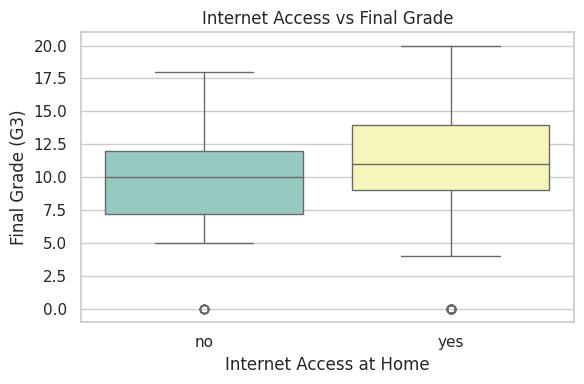

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="internet", y="G3", data=df, palette="Set3")
plt.title("Internet Access vs Final Grade")
plt.xlabel("Internet Access at Home")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1511/3839711836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Dalc", y="G3", data=df, palette="Reds")


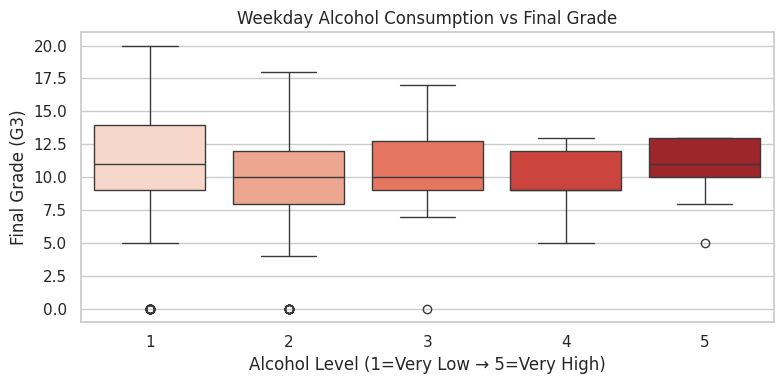

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Dalc", y="G3", data=df, palette="Reds")
plt.title("Weekday Alcohol Consumption vs Final Grade")
plt.xlabel("Alcohol Level (1=Very Low → 5=Very High)")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

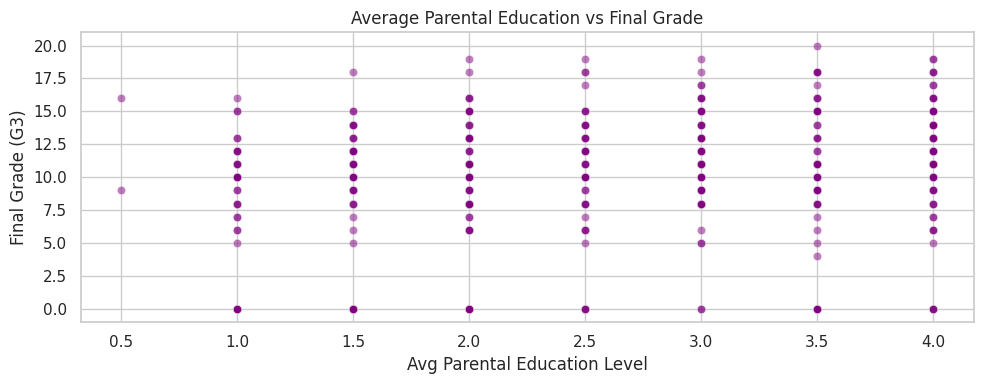

In [13]:
plt.figure(figsize=(10, 4))
df["parent_edu"] = (df["Medu"] + df["Fedu"]) / 2
sns.scatterplot(x="parent_edu", y="G3", data=df, alpha=0.5, color="purple")
plt.title("Average Parental Education vs Final Grade")
plt.xlabel("Avg Parental Education Level")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

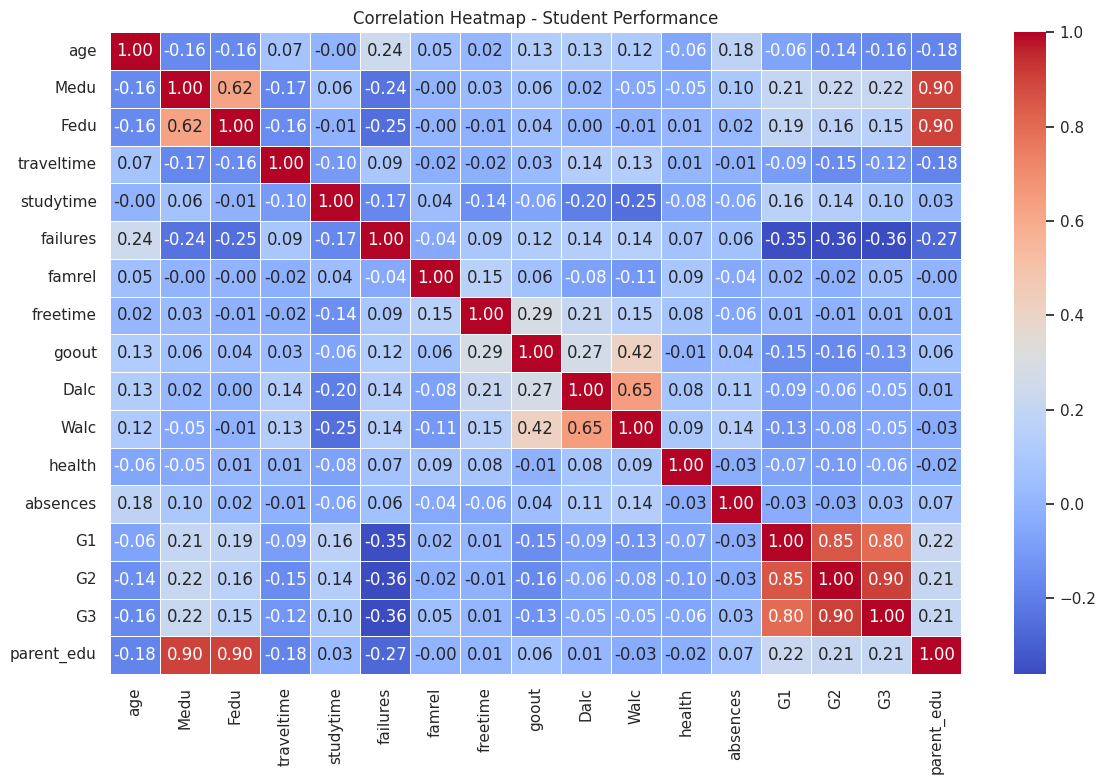

In [14]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Student Performance")
plt.tight_layout()
plt.show()

In [15]:
internet_yes = df[df["internet"] == "yes"]["G3"]
internet_no  = df[df["internet"] == "no"]["G3"]

t_stat, p_value = stats.ttest_ind(internet_yes, internet_no)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant difference — internet access DOES affect grades!")
else:
    print("❌ No significant difference found.")

T-statistic : 1.9619
P-value     : 0.0505
❌ No significant difference found.


In [16]:
female = df[df["sex"] == "F"]["G3"]
male   = df[df["sex"] == "M"]["G3"]

t_stat2, p_value2 = stats.ttest_ind(female, male)
print(f"T-statistic : {t_stat2:.4f}")
print(f"P-value     : {p_value2:.4f}")

if p_value2 < 0.05:
    print("✅ Significant gender difference in grades!")
else:
    print("❌ No significant gender difference found.")

T-statistic : -2.0620
P-value     : 0.0399
✅ Significant gender difference in grades!


In [17]:
# Cell 17: Automated EDA Summary
print("=" * 60)
print("     EDA SUMMARY — Student Performance Dataset")
print("=" * 60)

# Dataset basics
print(f"\n📦 Dataset Shape     : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"🔍 Missing Values    : {df.isnull().sum().sum()}")
print(f"👩‍🎓 Total Students    : {len(df)}")
print(f"📊 Numeric Columns   : {df.select_dtypes(include=np.number).shape[1]}")
print(f"🔤 Categorical Cols  : {df.select_dtypes(include='object').shape[1]}")

# Grade stats
print("\n📈 Final Grade (G3) Statistics:")
print(f"   Average Grade     : {df['G3'].mean():.2f}")
print(f"   Highest Grade     : {df['G3'].max()}")
print(f"   Lowest Grade      : {df['G3'].min()}")
print(f"   Students with 0   : {(df['G3'] == 0).sum()} ⚠️ (possible dropouts)")

# Study time
best_study = df.groupby("studytime")["G3"].mean().idxmax()
print(f"\n📚 Study Time vs Grade:")
print(df.groupby("studytime")["G3"].mean().round(2).to_string())
print(f"   Best study group  : Level {best_study}")

# Gender
print(f"\n⚤  Average Grade by Gender:")
print(df.groupby("sex")["G3"].mean().round(2).to_string())

# Internet
print(f"\n🌐 Average Grade by Internet Access:")
print(df.groupby("internet")["G3"].mean().round(2).to_string())

# Alcohol
print(f"\n🍺 Average Grade by Weekday Alcohol Level:")
print(df.groupby("Dalc")["G3"].mean().round(2).to_string())

# Top correlations with G3
print(f"\n🔗 Top Features Correlated with Final Grade (G3):")
corr = df.select_dtypes(include=np.number).corr()["G3"].drop("G3").sort_values(ascending=False)
print(corr.head(5).round(3).to_string())

print("\n" + "=" * 60)
print("✅ EDA Complete!")
print("=" * 60)

     EDA SUMMARY — Student Performance Dataset

📦 Dataset Shape     : 395 rows × 34 columns
🔍 Missing Values    : 0
👩‍🎓 Total Students    : 395
📊 Numeric Columns   : 17
🔤 Categorical Cols  : 17

📈 Final Grade (G3) Statistics:
   Average Grade     : 10.42
   Highest Grade     : 20
   Lowest Grade      : 0
   Students with 0   : 38 ⚠️ (possible dropouts)

📚 Study Time vs Grade:
studytime
1    10.05
2    10.17
3    11.40
4    11.26
   Best study group  : Level 3

⚤  Average Grade by Gender:
sex
F     9.97
M    10.91

🌐 Average Grade by Internet Access:
internet
no      9.41
yes    10.62

🍺 Average Grade by Weekday Alcohol Level:
Dalc
1    10.73
2     9.25
3    10.50
4     9.89
5    10.67

🔗 Top Features Correlated with Final Grade (G3):
G2            0.905
G1            0.801
Medu          0.217
parent_edu    0.205
Fedu          0.152

✅ EDA Complete!
